### (a)
Generate a simulated data set with 20 observations in each of
three classes (i.e. 60 observations total), and 50 variables.
Hint: There are a number of functions in Python that you can
use to generate data. One example is the normal() method of
the random() function in numpy; the uniform() method is another
option. Be sure to add a mean shift to the observations in each
class so that there are three distinct classes

In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

np.random.seed(42)

n_class = 3     
n_obs = 20       
n_var = 50      

class_1 = np.random.normal(loc=0, scale=1, size=(n_obs, n_var))
class_2 = np.random.normal(loc=1, scale=0.8, size=(n_obs, n_var))
class_3 = np.random.normal(loc=2, scale=1.2, size=(n_obs, n_var))

X = np.vstack([class_1, class_2, class_3])
                         
y = np.array([0]*n_obs + [1]*n_obs + [2]*n_obs)

### (b)
Perform PCA on the 60 observations and plot the first two prin-
cipal component score vectors. Use a different color to indicate
the observations in each of the three classes. If the three classes
appear separated in this plot, then continue on to part (c). If
not, then return to part (a) and modify the simulation so that
there is greater separation between the three classes. Do not
continue to part (c) until the three classes show at least some
separation in the first two principal component score vectors.

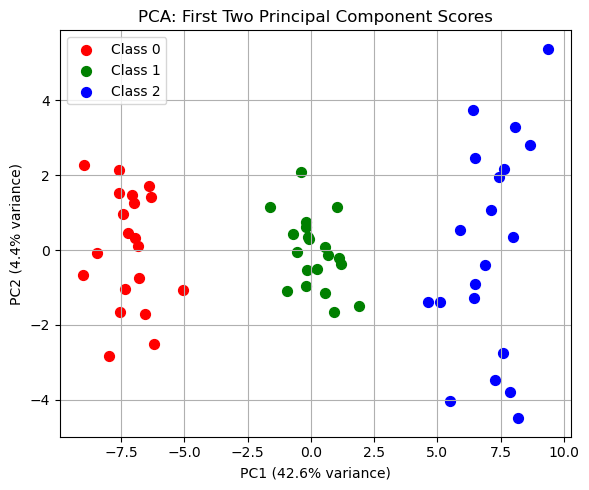

In [34]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

plt.figure(figsize=(6,5))
colors = ['red', 'green', 'blue']

for cls in [0, 1, 2]:
    plt.scatter(X_pca[y == cls, 0],
                X_pca[y == cls, 1],
                color=colors[cls],
                s=50,
                label=f'Class {cls}')

plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
plt.title('PCA: First Two Principal Component Scores')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### (c)
Perform K-means clustering of the observations with K = 3.
How well do the clusters that you obtained in K-means cluster-
ing compare to the true class labels?
Hint: You can use the pd.crosstab() function in Python to com-
pare the true class labels to the class labels obtained by cluster-
ing. Be careful how you interpret the results: K-means clustering
will arbitrarily number the clusters, so you cannot simply check
whether the true class labels and clustering labels are the same.

K-means Cluster   0   1   2
True Class                 
0                 0   0  20
1                 0  20   0
2                20   0   0


C:\Users\jack9\python\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\jack9\AppData\Local\Temp\ipykernel_17276\1277517581.py:12: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(X_pca[idx, 0], X_pca[idx, 1],


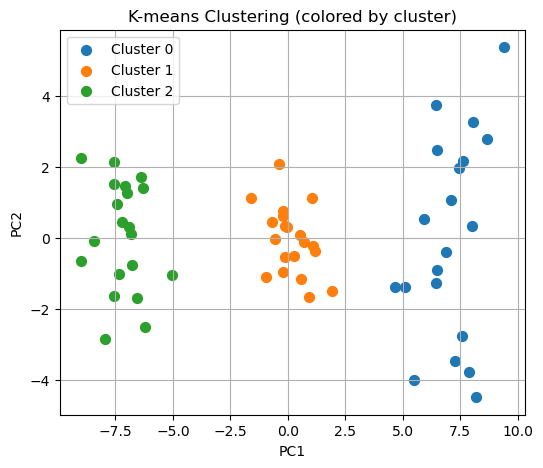

In [35]:
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X)

comparison = pd.crosstab(y, clusters,
                         rownames=['True Class'],
                         colnames=['K-means Cluster'])
print(comparison)

plt.figure(figsize=(6,5))
for cluster_id in np.unique(clusters):
    idx = clusters == cluster_id
    plt.scatter(X_pca[idx, 0], X_pca[idx, 1],
                s=50, label=f'Cluster {cluster_id}', cmap='viridis')

plt.title("K-means Clustering (colored by cluster)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.grid(True)
plt.show()

### (d)
Perform K-means clustering with K = 2. Describe your results.

K-means Cluster   0   1
True Class             
0                20   0
1                19   1
2                 0  20


C:\Users\jack9\python\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\jack9\AppData\Local\Temp\ipykernel_17276\2659201745.py:12: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(X_pca[idx, 0], X_pca[idx, 1],


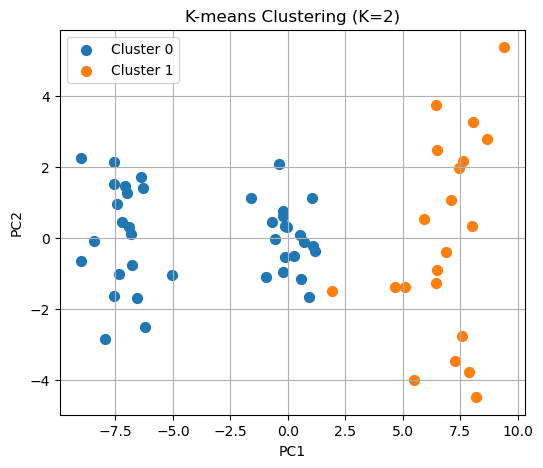

In [36]:
kmeans2 = KMeans(n_clusters=2, random_state=42)
clusters2 = kmeans2.fit_predict(X)

comparison2 = pd.crosstab(y, clusters2,
                          rownames=['True Class'],
                          colnames=['K-means Cluster'])
print(comparison2)

plt.figure(figsize=(6,5))
for cluster_id in np.unique(clusters2):
    idx = (clusters2 == cluster_id)
    plt.scatter(X_pca[idx, 0], X_pca[idx, 1],
                s=50,
                label=f'Cluster {cluster_id}',
                cmap='coolwarm')

plt.title('K-means Clustering (K=2)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend()
plt.grid(True)
plt.show()

當K=2 時，K-means 將左邊的兩群歸為同一群，右邊則獨立成另一群，因為三個群距離太近，演算法認為兩個群就足以描述資料結構。

### (e)
Now perform K-means clustering with K = 4, and describe your
results.

K-means Cluster  0   1   2   3
True Class                    
0                0   0  20   0
1                9  11   0   0
2                1   1   0  18


C:\Users\jack9\python\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\jack9\AppData\Local\Temp\ipykernel_17276\3116972146.py:12: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(X_pca[idx, 0], X_pca[idx, 1],


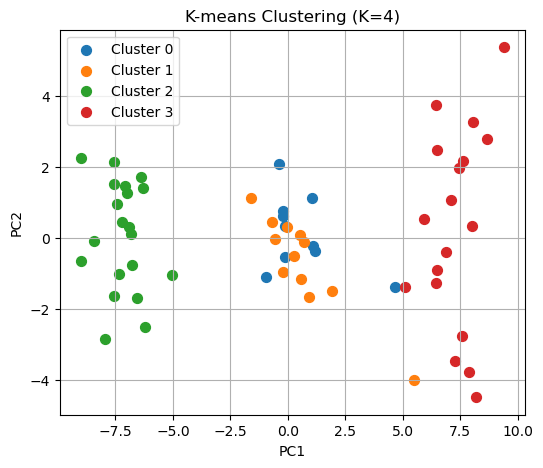

In [37]:
kmeans4 = KMeans(n_clusters=4, random_state=42)
clusters4 = kmeans4.fit_predict(X)

comparison4 = pd.crosstab(y, clusters4,
                          rownames=['True Class'],
                          colnames=['K-means Cluster'])
print(comparison4)

plt.figure(figsize=(6,5))
for cluster_id in np.unique(clusters4):
    idx = (clusters4 == cluster_id)
    plt.scatter(X_pca[idx, 0], X_pca[idx, 1],
                s=50,
                label=f'Cluster {cluster_id}',
                cmap='tab10')

plt.title('K-means Clustering (K=4)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend()
plt.grid(True)
plt.show()

K-means 嘗試找到四個中心點，但實際上資料只有三群，因此演算法會把其中一群切成兩半，這代表 K 設太大會導致過度分群 (over-clustering)，使得分群結果與真實類別不對應。

### (f)
Now perform K-means clustering with K = 3 on the first two
principal component score vectors, rather than on the raw data.
That is, perform K-means clustering on the 60 × 2 matrix of
which the first column is the first principal component score
vector, and the second column is the second principal component
score vector. Comment on the results.

C:\Users\jack9\python\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


col_0   0   1   2
row_0            
0       0   0  20
1      20   0   0
2       0  20   0

分類準確率： 100.00%


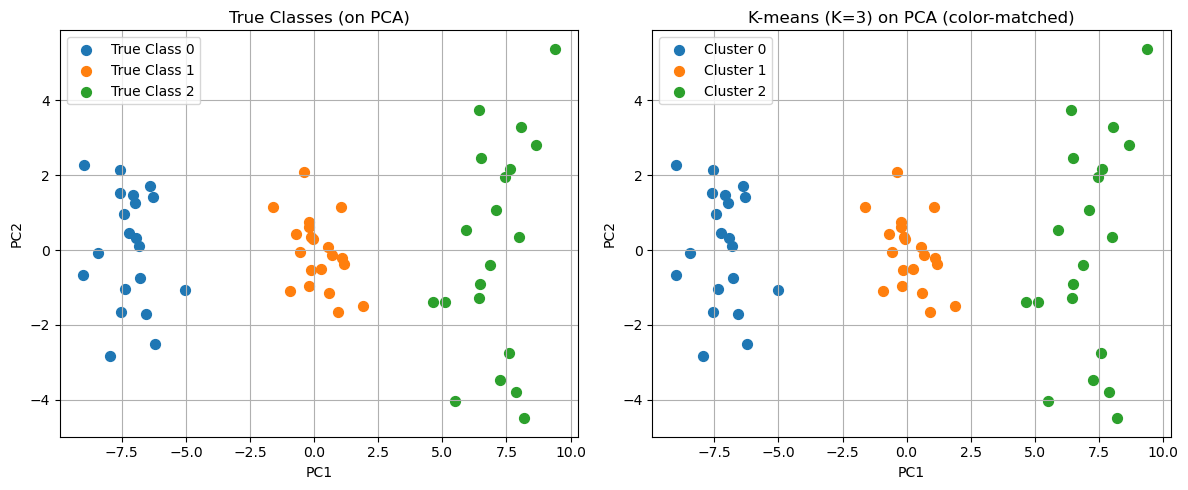

In [44]:
kmeans_pca = KMeans(n_clusters=3, random_state=42)
clusters_pca = kmeans_pca.fit_predict(X_pca)

table = pd.crosstab(y, clusters_pca)
print(table)

mapping = {}
for cluster in table.columns:
    mapping[cluster] = table[cluster].idxmax()

clusters_mapped = np.array([mapping[c] for c in clusters_pca])

correct = sum(table.max(axis=1))
accuracy = correct / len(y) * 100
print(f"\n分類準確率： {accuracy:.2f}%")

plt.figure(figsize=(12,5))
colors = ['tab:blue', 'tab:orange', 'tab:green']
#pic 1
plt.subplot(1,2,1)
for cls in np.unique(y):
    plt.scatter(X_pca[y==cls,0], X_pca[y==cls,1],
                s=50, color=colors[cls], label=f'True Class {cls}')
plt.title('True Classes (on PCA)')
plt.xlabel('PC1'); plt.ylabel('PC2')
plt.legend(); plt.grid(True)

#pic 2
plt.subplot(1,2,2)
for cls in np.unique(clusters_mapped):
    plt.scatter(X_pca[clusters_mapped==cls,0], X_pca[clusters_mapped==cls,1],
                s=50, color=colors[cls], label=f'Cluster {cls}')
plt.title('K-means (K=3) on PCA (color-matched)')
plt.xlabel('PC1'); plt.ylabel('PC2')
plt.legend(); plt.grid(True)

plt.tight_layout()
plt.show()

與原始幾乎一致

### (g)
Using the StandardScaler() estimator, perform K-means clus-
tering with K = 3 on the data after scaling each variable to have
standard deviation one. How do these results compare to those
obtained in (b)? Explain.

In [45]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kmeans_scaled = KMeans(n_clusters=3, random_state=42)
clusters_scaled = kmeans_scaled.fit_predict(X_scaled)

table = pd.crosstab(y, clusters_scaled,
                    rownames=['True Class'],
                    colnames=['K-means Cluster (scaled)'])
print(table)

correct = sum(table.max(axis=1))
accuracy = correct / len(y) * 100
print(f"\n分類準確率： {accuracy:.2f}%")

K-means Cluster (scaled)   0   1   2
True Class                          
0                          0   0  20
1                          0  20   0
2                         20   0   0

分類準確率： 100.00%


C:\Users\jack9\python\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


原本的資料每個變數的Scaler差不多，標準化後結果幾乎一樣